# Solve partial differential equations

This tutorial replicates Figure 1 from https://arxiv.org/abs/2110.11812,
but uses some advanced features in Probdiffeq, namely, solving matrix-valued problems
and adaptive simulation with fixedpoint smoothing.

In [1]:
"""Solve a PDE."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probdiffeq import ivpsolve, probdiffeq

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main() -> None:
    """Simulate a PDE."""
    key = jax.random.PRNGKey(1)
    f, (u0,), (t0, t1) = fhn_2d(key, num=40, t1=10.0)

    def vf(y, /, *, t):  # noqa: ARG001
        """Evaluate the dynamics of the PDE."""
        return f(y)

    print("Problem dimension:", u0.size)

    # Set up a state-space model
    tcoeffs = [u0, vf(u0, t=t0)]
    init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="blockdiag")
    iwp = probdiffeq.prior_wiener_integrated(ssm=ssm)

    # Build a solver
    ts = probdiffeq.constraint_ode_ts1(vf, ssm=ssm)
    strategy = probdiffeq.strategy_smoother_fixedpoint(ssm=ssm)
    solver = probdiffeq.solver_dynamic(
        ssm=ssm, strategy=strategy, prior=iwp, constraint=ts
    )
    error = probdiffeq.error_residual_std(constraint=ts, prior=iwp, ssm=ssm)

    # Solve the ODE
    save_at = jnp.linspace(t0, t1, num=5, endpoint=True)
    simulate = simulator(save_at=save_at, error=error, solver=solver)
    (u, u_std) = simulate(init)

    _fig, axes = plt.subplots(
        nrows=2, ncols=len(u), figsize=(2 * len(u), 3), tight_layout=True
    )
    for t_i, u_i, std_i, ax_i in zip(save_at, u, u_std, axes.T):
        ax_i[0].set_title(f"t = {t_i:.1f}", fontsize="medium")
        img = ax_i[0].imshow(u_i[0], cmap="copper", vmin=-1, vmax=1)
        plt.colorbar(img)

        uncertainty = jnp.log10(jnp.abs(std_i[0]) + 1e-10)
        img = ax_i[1].imshow(uncertainty, cmap="bone", vmin=-7, vmax=-3)
        plt.colorbar(img)

        ax_i[0].set_xticks(())
        ax_i[1].set_xticks(())
        ax_i[0].set_yticks(())
        ax_i[1].set_yticks(())

    axes[0][0].set_ylabel("PDE solution", fontsize="medium")
    axes[1][0].set_ylabel("log(std)", fontsize="medium")
    plt.show()

In [2]:
def simulator(save_at, error, solver):
    """Simulate a PDE."""

    @jax.jit
    def solve(init):
        solve = ivpsolve.solve_adaptive_save_at(error=error, solver=solver)
        solution = solve(init, save_at=save_at, atol=1e-4, rtol=1e-2)
        return (solution.u.mean[0], solution.u.std[0])

    return solve

In [3]:
def fhn_2d(prng_key, *, num, t1, t0=0.0, a=2.8e-4, b=5e-3, k=-0.005, tau=1.0):
    """Construct the FitzHugh-Nagumo PDE.

    Source: https://github.com/pnkraemer/tornadox/blob/main/tornadox/ivp.py

    But simplified since Probdiffeq can handle matrix-valued ODEs.
    Here, we also set tau = 1.0 to make the example quick to execute.
    """
    y0 = jax.random.uniform(prng_key, shape=(2, num, num))

    @jax.jit
    def fhn_2d(x):
        u, v = x
        du = _laplace_2d(u, dx=1.0 / num)
        dv = _laplace_2d(v, dx=1.0 / num)
        u_new = a * du + u - u**3 - v + k
        v_new = (b * dv + u - v) / tau
        return jnp.stack((u_new, v_new))

    return fhn_2d, (y0,), (t0, t1)


def _laplace_2d(grid, dx):
    """2D Laplace operator on a vectorized 2d grid."""
    # Set the boundary values to the nearest interior node
    # This enforces Neumann conditions.
    padded_grid = jnp.pad(grid, pad_width=1, mode="edge")

    # Laplacian via convolve2d()
    kernel = jnp.array([[0.0, 1.0, 0.0], [1.0, -4.0, 1.0], [0.0, 1.0, 0.0]])
    kernel /= dx**2
    grid = jax.scipy.signal.convolve2d(padded_grid, kernel, mode="same")
    return grid[1:-1, 1:-1]

Problem dimension: 3200


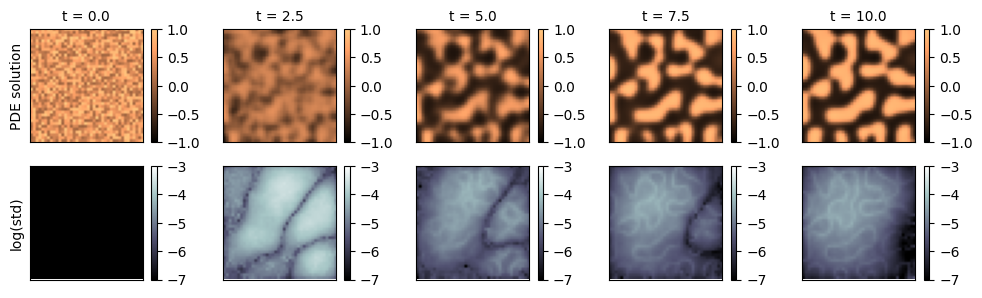

In [4]:
if __name__ == "__main__":
    main()